# ניסוי מועמד לגרסה 2: Elo + H2H + DNA

מחברת זו מתעדת מועמד שנבדק ולא נבחר לייצור. היא מחברת שלוש משפחות מידע: דירוגי Elo נקודתיים בזמן, היסטוריית מפגשים ישירים שנצפתה לפני כל משחק, ופרופיל DNA של קבוצה ומפה. לאחר חלוקת זמן נעולה וסימטריזציה נפרדת, Optuna מחפש היפר־פרמטרים ל־XGBoost לפי לוג־לוס בחלוקת האימות. התוצאה הסופית במחברת מראה שהשילוב פגע בביצועים; לכן רצף המחקר ממשיך ב־Notebook 03 למחקרי הסרה מבוקרים, והמודל הייצורי שננעל בהמשך הוא Elo קנוני בלבד.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from optuna.samplers import TPESampler
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from xgboost import XGBClassifier

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent
elo_module_dir = project_root / "src" / "features"
if str(elo_module_dir) not in sys.path:
    sys.path.insert(0, str(elo_module_dir))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from elo import PointInTimeEngine
from src.data.splitter import ChronologicalSplitter

RANDOM_SEED = 42

Matplotlib is building the font cache; this may take a moment.


## Elo ומפגשים ישירים בנקודת הזמן הנכונה

המנוע עובר על המפות בסדר כרונולוגי. פיצ'רי Elo נשמרים לפני עדכון תוצאת המפה. מוני המפגשים הישירים נשמרים לפני המשחק כולו: כל המפות השייכות לאותו `match_id` מקבלות את אותה היסטוריה קודמת, ורק לאחר מכן תוצאות המשחק מתווספות למונים. כך מפה מאוחרת בסדרת Bo3 אינה מקבלת מידע H2H שנוצר בתוך אותה סדרה.

מזהי הקבוצה המספריים בקובץ המקור אינם יציבים בין משחקים. לכן המנוע מעדיף את מפתח החיבור הקנוני של הקבוצה, ורק בהיעדרו חוזר למזהה המקורי. החלטה זו חיונית כדי שהיסטוריית Elo ו־H2H תצטבר בין טורנירים.

In [2]:
source_columns = [
    "match_id", "game_id", "tournament",
    "team1_id", "team1", "team2_id", "team2",
    "is_total", "bestOf", "score1_game", "score2_game",
    "map_id", "map_name", "datetime", "team1_win",
    "team1_join_key", "team2_join_key",
]
source_path = project_root / "data" / "final_tournament_features.csv"
source_df = pd.read_csv(source_path, usecols=source_columns, low_memory=False)
point_in_time_df = PointInTimeEngine(k_factor=24, initial_rating=1500).transform(source_df)

h2h_coverage = (
    point_in_time_df["team1_h2h_wins"] + point_in_time_df["team2_h2h_wins"]
).gt(0).mean()
print(f"מספר מפות תקינות: {len(point_in_time_df):,}")
print(f"שיעור המפות עם היסטוריית מפגש קודמת: {h2h_coverage:.1%}")
print(f"הנתונים ממוינים כרונולוגית: {point_in_time_df['datetime'].is_monotonic_increasing}")

מספר מפות תקינות: 6,700
שיעור המפות עם היסטוריית מפגש קודמת: 52.5%
הנתונים ממוינים כרונולוגית: True


## חיבור DNA לפי קבוצה ומפה

טבלת ה־DNA מכילה שיעורי ניצחון בסיבובי פיסטול, בצד CT ובצד T, יחד עם מספר התצפיות שעליהן כל שיעור מבוסס. החיבור מתבצע באמצעות מפתח קבוצה קנוני ושם מפה, ונבדק כחיבור רבים־לאחד כדי למנוע הכפלת שורות. כפילויות שנבדלות רק באותיות גדולות וקטנות מאוחדות בממוצע משוקלל לפי מספר הסיבובים.

חשוב: ה־DNA הוא פרופיל סטטי מחלון אוגוסט 2024 עד אוקטובר 2025 ואינו פיצ'ר מתגלגל נקודתי בזמן. לכן קיימת חפיפה ידועה בתוך תקופת האימון. חלוקות 2026 מגיעות לאחר חלון בניית ה־DNA, אך יש לפרש את מדדי הביניים בזהירות. ערכים חסרים נשארים `NaN`, ו־XGBoost מטפל בהם באמצעות פיצולים מודעי־חסרות; לא מתבצעת השלמה מלאכותית ל־0.5.

In [3]:
dna_path = project_root / "data" / "team_dna_features.csv"
dna_raw = pd.read_csv(dna_path)
dna_raw["dna_team_key"] = dna_raw["team"].astype("string").str.strip().str.casefold()

dna_rate_count_pairs = {
    "pistol_round_win_rate": "n_pistol_rounds",
    "ct_win_rate": "n_ct_rounds",
    "t_win_rate": "n_t_rounds",
}

def collapse_dna_group(group):
    collapsed = {}
    for rate_column, count_column in dna_rate_count_pairs.items():
        values = pd.to_numeric(group[rate_column], errors="coerce")
        weights = pd.to_numeric(group[count_column], errors="coerce").fillna(0)
        valid = values.notna() & weights.gt(0)
        collapsed[count_column] = int(weights[valid].sum())
        collapsed[rate_column] = (
            np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan
        )
    return pd.Series(collapsed)

dna = (
    dna_raw.groupby(["dna_team_key", "map_name"], sort=False)
    .apply(collapse_dna_group, include_groups=False)
    .reset_index()
)
if dna.duplicated(["dna_team_key", "map_name"]).any():
    raise AssertionError("DNA keys are not unique after weighted collapse.")

dna_value_columns = list(dna_rate_count_pairs) + list(dna_rate_count_pairs.values())

def merge_dna_for_side(frame, side):
    lookup_key = f"team{side}_dna_lookup_key"
    rename_columns = {
        "dna_team_key": lookup_key,
        **{column: f"team{side}_{column}" for column in dna_value_columns},
    }
    side_dna = dna.rename(columns=rename_columns)
    before_rows = len(frame)
    merged = frame.merge(
        side_dna,
        how="left",
        left_on=[f"team{side}_join_key", "map_name"],
        right_on=[lookup_key, "map_name"],
        validate="many_to_one",
        sort=False,
    ).drop(columns=lookup_key)
    if len(merged) != before_rows:
        raise AssertionError(f"DNA join changed row count for team side {side}.")
    return merged

integrated_df = merge_dna_for_side(point_in_time_df, 1)
integrated_df = merge_dna_for_side(integrated_df, 2)
team1_rate_columns = [f"team1_{column}" for column in dna_rate_count_pairs]
team2_rate_columns = [f"team2_{column}" for column in dna_rate_count_pairs]
integrated_df["team1_has_dna"] = integrated_df[team1_rate_columns].notna().all(axis=1)
integrated_df["team2_has_dna"] = integrated_df[team2_rate_columns].notna().all(axis=1)

print(f"מפתחות DNA ייחודיים לאחר איחוד: {len(dna):,}")
print(f"כיסוי DNA לקבוצה 1: {integrated_df['team1_has_dna'].mean():.1%}")
print(f"כיסוי DNA לקבוצה 2: {integrated_df['team2_has_dna'].mean():.1%}")
print(f"מספר שורות לאחר החיבור: {len(integrated_df):,}")

מפתחות DNA ייחודיים לאחר איחוד: 4,954
כיסוי DNA לקבוצה 1: 93.6%
כיסוי DNA לקבוצה 2: 92.2%
מספר שורות לאחר החיבור: 6,700


## חלוקת זמן נעולה וסימטריזציה עצמאית

הנתונים נחלקים לאימון עד סוף 2025, אימות ברבעון הראשון של 2026 ובדיקה מאפריל 2026. רק Train ו־Validation עוברים סימטריזציה; חלוקת Test נשארת נעולה ללא שינוי. בכל עותק משוקף מוחלפים כל הפיצ'רים הדו־צדדיים, התווית מתהפכת והסתברויות Elo משלימות ל־1.

פיצ'רי ההפרש מחושבים לאחר ההחלפה: Elo גלובלי, Elo למפה, ניצחונות H2H ושלושת שיעורי ה־DNA. בדיקה אנטי־סימטרית דורשת שכל הפרש בעותק המשוקף יהיה שווה למינוס ההפרש המקורי, כולל שמירה נכונה על `NaN`.

In [4]:
splits = ChronologicalSplitter().split(integrated_df)
train_base = splits["train"]
val_base = splits["val"]
locked_test_rows = len(splits["test"])

elo_pair_columns = [
    ("team1_elo_global", "team2_elo_global"),
    ("team1_elo_map", "team2_elo_map"),
    ("team1_map_elo_n_games", "team2_map_elo_n_games"),
    ("team1_h2h_wins", "team2_h2h_wins"),
]
dna_pair_columns = [
    (f"team1_{column}", f"team2_{column}") for column in dna_value_columns
]
identity_pair_columns = [
    ("team1_id", "team2_id"),
    ("team1", "team2"),
    ("team1_join_key", "team2_join_key"),
    ("team1_has_dna", "team2_has_dna"),
]
swap_pairs = identity_pair_columns + elo_pair_columns + dna_pair_columns
base_model_columns = [column for pair in elo_pair_columns + dna_pair_columns for column in pair]
base_model_columns += [
    "raw_global_elo_prob", "raw_map_elo_prob",
    "team1_has_dna", "team2_has_dna",
]
context_columns = [
    "match_id", "game_id", "datetime", "map_name",
    "team1_id", "team1", "team2_id", "team2",
    "team1_join_key", "team2_join_key", "team1_win",
]
diff_pairs = {
    "elo_global_diff": ("team1_elo_global", "team2_elo_global"),
    "elo_map_diff": ("team1_elo_map", "team2_elo_map"),
    "h2h_wins_diff": ("team1_h2h_wins", "team2_h2h_wins"),
    "dna_pistol_diff": ("team1_pistol_round_win_rate", "team2_pistol_round_win_rate"),
    "dna_ct_diff": ("team1_ct_win_rate", "team2_ct_win_rate"),
    "dna_t_diff": ("team1_t_win_rate", "team2_t_win_rate"),
}

def symmetrize_split(split_df):
    selected_columns = list(dict.fromkeys(context_columns + base_model_columns))
    original = split_df[selected_columns].copy().reset_index(drop=True)
    mirrored = original.copy()
    for team1_column, team2_column in swap_pairs:
        mirrored[team1_column] = original[team2_column].to_numpy(copy=True)
        mirrored[team2_column] = original[team1_column].to_numpy(copy=True)
    mirrored["team1_win"] = 1 - original["team1_win"].to_numpy()
    mirrored["raw_global_elo_prob"] = 1 - original["raw_global_elo_prob"].to_numpy()
    mirrored["raw_map_elo_prob"] = 1 - original["raw_map_elo_prob"].to_numpy()

    symmetric = pd.concat([original, mirrored], ignore_index=True)
    for diff_column, (team1_column, team2_column) in diff_pairs.items():
        symmetric[diff_column] = symmetric[team1_column] - symmetric[team2_column]

    midpoint = len(original)
    for diff_column in diff_pairs:
        original_values = symmetric.iloc[:midpoint][diff_column].to_numpy()
        mirrored_values = symmetric.iloc[midpoint:][diff_column].to_numpy()
        if not np.allclose(original_values, -mirrored_values, equal_nan=True):
            raise AssertionError(f"Diff sign did not flip: {diff_column}")
    if len(symmetric) != 2 * len(original):
        raise AssertionError("Symmetrization did not double the split.")
    if not np.isclose(symmetric["team1_win"].mean(), 0.5):
        raise AssertionError("Symmetrization did not balance the target.")
    return symmetric

train_df = symmetrize_split(train_base)
val_df = symmetrize_split(val_base)
feature_columns = base_model_columns + list(diff_pairs)
X_train = train_df[feature_columns]
y_train = train_df["team1_win"].astype(int)
X_val = val_df[feature_columns]
y_val = val_df["team1_win"].astype(int)

if not all(pd.api.types.is_numeric_dtype(X_train[column]) for column in feature_columns):
    raise TypeError("The V2 feature allowlist must contain only numeric columns.")

print(f"Train לפני ואחרי סימטריזציה: {len(train_base):,} ← {len(train_df):,}")
print(f"Validation לפני ואחרי סימטריזציה: {len(val_base):,} ← {len(val_df):,}")
print(f"Test נעול וללא סימטריזציה: {locked_test_rows:,}")
print(f"מספר פיצ'רים מאושרים: {len(feature_columns)}")

Train לפני ואחרי סימטריזציה: 5,472 ← 10,944
Validation לפני ואחרי סימטריזציה: 633 ← 1,266
Test נעול וללא סימטריזציה: 595
מספר פיצ'רים מאושרים: 30


## אופטימיזציה בייסיאנית באמצעות Optuna

במקום לבדוק רשת קבועה של שילובים, דוגם TPE לומד מתוצאות הניסויים הקודמים ומקדיש בהדרגה יותר ניסויים לאזורים מבטיחים. פונקציית המטרה מאמנת מודל על Train ומחזירה את הלוג־לוס על Validation; Optuna ממזער ערך זה במשך 50 ניסויים.

עומק העצים שולט במורכבות האינטראקציות, קצב הלמידה שולט בגודל כל עדכון, דגימת השורות והעמודות מוסיפה אקראיות שמפחיתה התאמת יתר, ו־L1/L2 מענישים משקלים מורכבים. בכל ניסוי עצירה מוקדמת בוחרת את מספר העצים בפועל. חלוקת Test אינה משתתפת בחיפוש.

In [5]:
def build_xgb_model(parameters):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=1200,
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        early_stopping_rounds=50,
        **parameters,
    )

def objective(trial):
    parameters = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
    }
    model = build_xgb_model(parameters)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    probability = model.predict_proba(X_val)[:, 1]
    trial.set_user_attr("best_iteration", int(model.best_iteration))
    return log_loss(y_val, probability, labels=[0, 1])

sampler = TPESampler(seed=RANDOM_SEED, n_startup_trials=10)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50, gc_after_trial=True, show_progress_bar=False)

print(f"מספר ניסויים שהושלמו: {len(study.trials)}")
print(f"הלוג־לוס הטוב ביותר בחיפוש: {study.best_value:.6f}")
print("הפרמטרים הטובים ביותר:")
for parameter_name, parameter_value in study.best_params.items():
    print(f"  {parameter_name}: {parameter_value}")

[I 2026-09-14 20:05:21,192] A new study created in memory with name: no-name-4be89591-b85b-452b-b01a-97945632f50c


[I 2026-09-14 20:05:22,212] Trial 0 finished with value: 0.6671302914619446 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 0.0060252157362038605}. Best is trial 0 with value: 0.6671302914619446.


[I 2026-09-14 20:05:23,395] Trial 1 finished with value: 0.6624082922935486 and parameters: {'max_depth': 3, 'learning_rate': 0.19030368381735815, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 70.72114131472235}. Best is trial 1 with value: 0.6624082922935486.


[I 2026-09-14 20:05:27,010] Trial 2 finished with value: 0.6655871868133545 and parameters: {'max_depth': 7, 'learning_rate': 0.020589728197687916, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.4205156450913872}. Best is trial 1 with value: 0.6624082922935486.


[I 2026-09-14 20:05:29,418] Trial 3 finished with value: 0.6621429920196533 and parameters: {'max_depth': 5, 'learning_rate': 0.02692655251486473, 'subsample': 0.8447411578889518, 'colsample_bytree': 0.6557975442608167, 'reg_alpha': 4.258943089524393e-06, 'reg_lambda': 0.06789053271698488}. Best is trial 3 with value: 0.6621429920196533.


...

[I 2026-09-14 20:08:03,580] Trial 46 finished with value: 0.6604334115982056 and parameters: {'max_depth': 5, 'learning_rate': 0.010869271574157674, 'subsample': 0.9579463593539742, 'colsample_bytree': 0.8384475548750914, 'reg_alpha': 1.7455742741729813e-08, 'reg_lambda': 0.02855082535185785}. Best is trial 24 with value: 0.6585701704025269.


[I 2026-09-14 20:08:07,614] Trial 47 finished with value: 0.6612180471420288 and parameters: {'max_depth': 6, 'learning_rate': 0.01152691340507351, 'subsample': 0.942716528387598, 'colsample_bytree': 0.7709301937157026, 'reg_alpha': 9.488750451233375e-07, 'reg_lambda': 0.02521068730243992}. Best is trial 24 with value: 0.6585701704025269.


[I 2026-09-14 20:08:09,913] Trial 48 finished with value: 0.6604169607162476 and parameters: {'max_depth': 5, 'learning_rate': 0.016786601620078858, 'subsample': 0.9944828149550695, 'colsample_bytree': 0.9762358717700489, 'reg_alpha': 3.8481517533836594e-07, 'reg_lambda': 0.15120604529424772}. Best is trial 24 with value: 0.6585701704025269.


[I 2026-09-14 20:08:12,848] Trial 49 finished with value: 0.6612690687179565 and parameters: {'max_depth': 6, 'learning_rate': 0.011164316294779472, 'subsample': 0.9652858584013237, 'colsample_bytree': 0.9958187925158604, 'reg_alpha': 3.296446483705867e-08, 'reg_lambda': 0.20393084837059}. Best is trial 24 with value: 0.6585701704025269.


מספר ניסויים שהושלמו: 50
הלוג־לוס הטוב ביותר בחיפוש: 0.658570
הפרמטרים הטובים ביותר:
  max_depth: 6
  learning_rate: 0.01049652555669452
  subsample: 0.9461941260236708
  colsample_bytree: 0.8635389854832652
  reg_alpha: 2.849555014221271e-07
  reg_lambda: 0.020848867377358166


## אימון חוזר של התצורה הנבחרת והערכת Validation

לאחר החיפוש נבנה מודל חדש עם ההיפר־פרמטרים שנבחרו. הוא מאומן שוב על Train בלבד, בעוד Validation משמש לעצירה מוקדמת ולהערכת המדדים הסופיים של שלב הפיתוח. ההשוואה היא לקו הבסיס המתועד של מודל Elo בלבד. מאחר שבצינור הסופי תוקנה גם זהות הקבוצה הקנונית, ההשוואה מודדת את שדרוג הצינור כולו ואינה בידוד טהור של תרומת DNA לבדה.

In [6]:
best_model = build_xgb_model(study.best_params)
best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10,
)

final_probability = best_model.predict_proba(X_val)[:, 1]
final_prediction = (final_probability >= 0.5).astype(int)
final_accuracy = accuracy_score(y_val, final_prediction)
final_log_loss = log_loss(y_val, final_probability, labels=[0, 1])
final_brier = brier_score_loss(y_val, final_probability)

ELO_ONLY_ACCURACY = 0.624013
ELO_ONLY_LOG_LOSS = 0.624156
ELO_ONLY_BRIER = 0.218974

print(f"האיטרציה הטובה ביותר במודל הסופי: {best_model.best_iteration}")
print(f"דיוק V2 סופי באימות: {final_accuracy:.6f}")
print(f"לוג־לוס V2 סופי באימות: {final_log_loss:.6f}")
print(f"ציון ברייר V2 סופי באימות: {final_brier:.6f}")
print(f"שינוי בדיוק מול Elo בלבד: {final_accuracy - ELO_ONLY_ACCURACY:+.6f}")
print(f"שיפור בלוג־לוס מול Elo בלבד: {ELO_ONLY_LOG_LOSS - final_log_loss:+.6f}")
print(f"שיפור בברייר מול Elo בלבד: {ELO_ONLY_BRIER - final_brier:+.6f}")

[0]	validation_0-logloss:0.69209	validation_1-logloss:0.69238


[10]	validation_0-logloss:0.68143	validation_1-logloss:0.68610


[20]	validation_0-logloss:0.67200	validation_1-logloss:0.68067


[30]	validation_0-logloss:0.66357	validation_1-logloss:0.67654


[40]	validation_0-logloss:0.65605	validation_1-logloss:0.67286


...

[200]	validation_0-logloss:0.58956	validation_1-logloss:0.65936


[210]	validation_0-logloss:0.58684	validation_1-logloss:0.65958


[220]	validation_0-logloss:0.58462	validation_1-logloss:0.65981


[222]	validation_0-logloss:0.58405	validation_1-logloss:0.65984


האיטרציה הטובה ביותר במודל הסופי: 172
דיוק V2 סופי באימות: 0.586888
לוג־לוס V2 סופי באימות: 0.658570
ציון ברייר V2 סופי באימות: 0.233393
שינוי בדיוק מול Elo בלבד: -0.037125
שיפור בלוג־לוס מול Elo בלבד: -0.034414
שיפור בברייר מול Elo בלבד: -0.014419


## תרשים אמינות

התרשים מקבץ את תחזיות Validation לעשירונים. התאמה לקו האלכסוני פירושה שהסתברות חזויה מסוימת מתממשת בשיעור דומה; סטייה מהקו מצביעה על צורך אפשרי בכיול נוסף לפני שימוש בסימולטור הברקט.

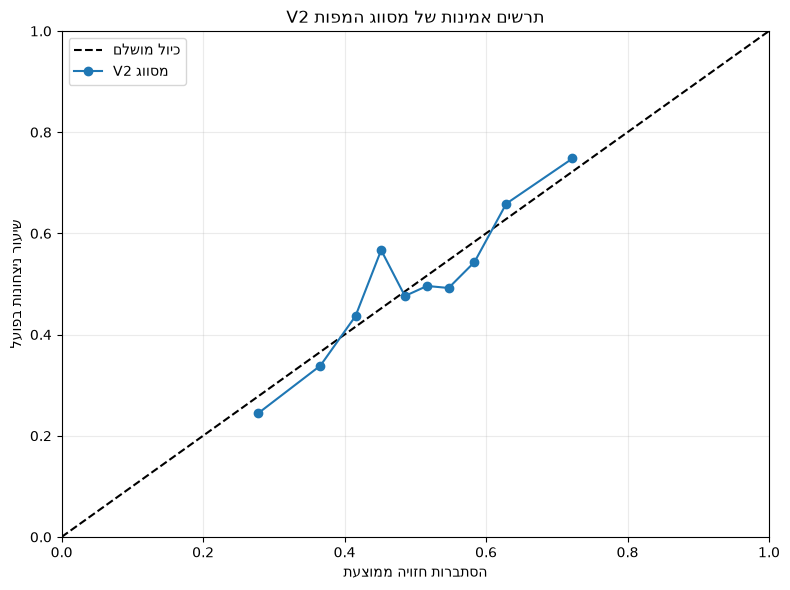

In [7]:
observed_rate, mean_probability = calibration_curve(
    y_val, final_probability, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="כיול מושלם")
ax.plot(mean_probability, observed_rate, marker="o", label="מסווג V2")
ax.set_title("תרשים אמינות של מסווג המפות V2")
ax.set_xlabel("הסתברות חזויה ממוצעת")
ax.set_ylabel("שיעור ניצחונות בפועל")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## מסקנה ונקודת עצירה

המודל הנבחר השיג דיוק של 0.586888, לוג־לוס של 0.658570 וציון ברייר של 0.233393. לעומת קו ה־Elo-only המתועד, הדיוק ירד ב־0.037125, הלוג־לוס הורע ב־0.034414 והברייר הורע ב־0.014419. לכן תוספת H2H ו־DNA בתצורה הנוכחית אינה מאושרת כשדרוג, ואין לפתוח עבורה את Test.

ההשוואה כוללת גם תיקון מהותי לזהות הקבוצה: המודל הקודם השתמש במזהים מספריים שאינם יציבים בין משחקים, בעוד הצינור הנוכחי משתמש במפתח קנוני. לכן הירידה אינה מוכיחה ש־DNA או H2H חסרי ערך בפני עצמם; היא מחייבת מחקרי הסרה נוספים על אותו מנוע זהות מתוקן. חלוקת Test נשארה ללא סימטריזציה, ללא חיזוי וללא מדדים.